[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/syaikhipin/kdd26-memdiag/blob/tutorial-rebuild/tutorial/phase1_memory_architectures/07_capstone.ipynb)

> **Run this notebook in Google Colab** — click the badge above. The setup cell auto-clones the repo.


# Phase 1G - Capstone (4 architectures)

**Phase 1G - Capstone: the four production architectures** - independent notebook.

Attribution: adapted from *Agent Memory Techniques* by Nir Diamant (https://github.com/NirDiamant/Agent_Memory_Techniques), Apache-2.0. Inline demos are original.

## 0. Setup (self-contained)

In [ ]:
# Self-contained setup - works standalone in Google Colab or locally.
import sys, os, subprocess
from pathlib import Path
REPO_URL = "https://github.com/syaikhipin/kdd26-memdiag"
try:
    import google.colab  # noqa
    IN_COLAB = True
except Exception:
    IN_COLAB = False
if IN_COLAB:
    repo = Path("/content/kdd26-memdiag")
    if not repo.exists():
        subprocess.run(["git", "clone", "--depth", "1", "--branch", "tutorial-rebuild", REPO_URL, str(repo)], check=False)
    SOURCE = repo / "source"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "numpy", "matplotlib", "pyyaml", "openai"], check=False)
else:
    SOURCE = None
    for cand in [Path.cwd(), *Path.cwd().parents]:
        for sub in ("source", "experiment"):
            if (cand / sub / "run.py").exists():
                SOURCE = cand / sub
                break
        if SOURCE:
            break
    if SOURCE is None:
        raise FileNotFoundError("Run from the repo root (or in Colab it auto-clones).")
sys.path.insert(0, str(SOURCE))
SOURCE_DIR = SOURCE
PROJECT_ROOT = SOURCE.parent
RESULTS_DIR = PROJECT_ROOT / "results"
try: _d = "<repo>/" + str(Path(SOURCE).relative_to(PROJECT_ROOT))
except Exception: _d = "<repo>/source"
print("SOURCE_DIR =", _d, "| found =", True, "| IN_COLAB =", IN_COLAB)

from embedder import TfidfHashEmbedder
from llm_client import LLMConfig, make_client, OfflineLLMClient
from memory_core import MemoryRecord
from providers import build_provider
emb = TfidfHashEmbedder()
TURNS = [
 ("Alice", "Hi, I am Alice. I work as a data scientist at a health-tech startup in Berlin."),
 ("Bob", "I am Bob, an ML engineer in Athens. I prefer PyTorch."),
 ("Alice", "We deploy on Kubernetes and track runs with Weights and Biases."),
 ("Bob", "Our training run failed last night with CUDA OOM at batch 256."),
 ("Alice", "We hit that before. Reducing batch to 64 and enabling gradient checkpointing fixed it."),
 ("Bob", "Our best val_loss was 0.423 with lr=3e-4 and weight_decay=0.01."),
 ("Alice", "I live in Prenzlauer Berg. My favorite coffee shop is on Kollwitzplatz."),
 ("Bob", "Let us sync next Tuesday at 10am CET."),
]
records = [MemoryRecord(f"t{i}", f"{w}: {t}", {"session_id": "s1" if i < 4 else "s2"}) for i, (w, t) in enumerate(TURNS)]
print("setup OK | turns =", len(TURNS))


## ⚙️ Set up your LLM at the beginning — base URL · API key · model
On first run this cell **prompts you for three things**: your OpenAI-compatible **base URL**, **API key** (hidden input), and **model**. They are saved to **Google Drive** in Colab (or a local file) so every other notebook and every future session reuses them — you set up **once**. Press **Enter** to keep a default / run offline. To reconfigure later: set `KDD_RECONFIG=1` or delete the saved config file shown below.

In [ ]:
# === Set up your LLM at the beginning: base URL · API key · model ===
# Prompts ONCE (saved to Google Drive in Colab / local file) -> reused by EVERY notebook & session.
# To re-prompt later: set os.environ['KDD_RECONFIG']='1', or delete the saved config file.
from config import setup_llm                       # shared helper in source/config.py
OPENAI_BASE_URL, OPENAI_API_KEY, OPENAI_MODEL = setup_llm()
from llm_client import LLMConfig, make_client
try:
    llm = make_client(LLMConfig(backend="openai-compatible" if OPENAI_API_KEY else "offline",
                                base_url=OPENAI_BASE_URL, model=OPENAI_MODEL))
    print("llm      =", llm.backend)
except Exception:
    llm = None
    print("llm      = (env vars set for CLI tools)")


## Compare all four architectures on one conversation

In [3]:
for name in ['no_memory','verbatim','extracted_facts','episodic','hybrid']:
 p = build_provider(name, emb, llm); p.ingest(records); it,_ = p.retrieve('What is Alices job?', 3)
 print(f'{name:16s} size={p.size():3d} top="{(it[0].content[:38] if it else "")}"')

no_memory        size=  0 top=""
verbatim         size=  8 top="Alice: I live in Prenzlauer Berg. My f"


extracted_facts  size= 26 top="Bob is in Athens."


episodic         size=  2 top="Alice is a data scientist at a Berlin "


hybrid           size= 10 top="Alice: Hi, I am Alice. I work as a dat"


### Visualize it — footprint vs. correct retrieval
Same conversation, four architectures. Bar = memory footprint; **green = retrieved Alice's job, red = missed**. Footprints differ ~10× and no single architecture dominates — the whole motivation for Phase 2 benchmarking.

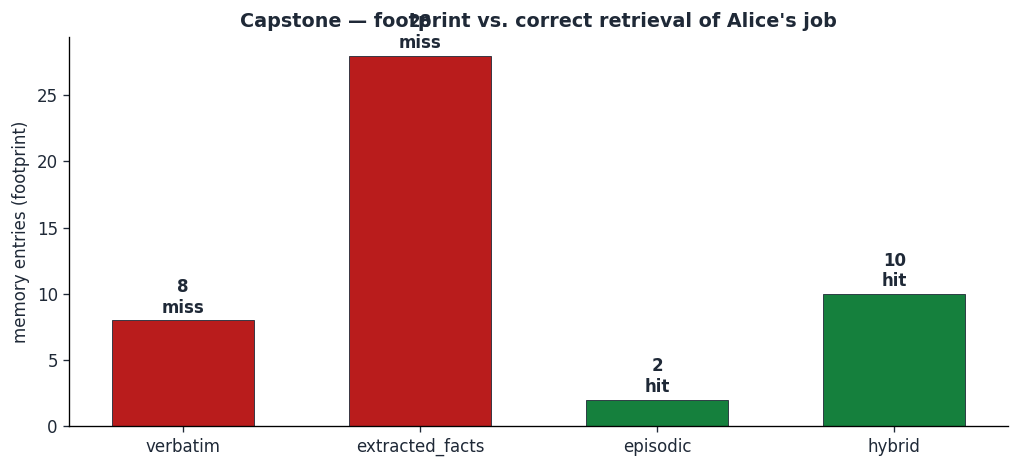

In [4]:
import matplotlib.pyplot as plt
PRIMARY='#1F2937'; GREEN='#15803D'; RED='#B91C1C'
names=[]; sizes=[]; hits=[]
for name in ['verbatim','extracted_facts','episodic','hybrid']:
    p = build_provider(name, emb, llm); p.ingest(records)
    it,_ = p.retrieve("What is Alice's job?", 3)
    top = it[0].content.lower() if it else ""
    hit = ('data scientist' in top) or ('health-tech' in top)
    names.append(name); sizes.append(p.size()); hits.append(hit)
fig,ax=plt.subplots(figsize=(8.6,4),dpi=120)
bars=ax.bar(names,sizes,color=[GREEN if h else RED for h in hits],edgecolor=PRIMARY,linewidth=0.5,width=0.6)
for b,s,h in zip(bars,sizes,hits):
    ax.text(b.get_x()+b.get_width()/2, s+max(sizes)*0.02, f"{s}\n{'hit' if h else 'miss'}",
            ha='center',fontsize=10,color=PRIMARY,weight='bold')
ax.set_ylabel('memory entries (footprint)',color=PRIMARY)
ax.set_title('Capstone — footprint vs. correct retrieval of Alice\'s job',color=PRIMARY,weight='bold',fontsize=11.5)
ax.spines[['top','right']].set_visible(False); ax.tick_params(colors=PRIMARY)
fig.tight_layout(); plt.show()

### Bridge to Phase 2
You've seen how each technique remembers. Phase 2 asks: on real benchmarks, which failures appear - and how do we measure them honestly?